In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [13]:
# Загружаем только нужные колонки из data_labeled
df_labeled = pd.read_csv("../data/data_labeled.csv", parse_dates=["Date"])
df_labeled = df_labeled[["Date", "ticker", "Close", "RSI", "EMA_20", "EMA_50",
                          "MACD", "MACD_signal", "BB_high", "BB_low", "BB_width"]]

# Загружаем макро признаки — убираем дублирующиеся колонки
df_macro = pd.read_csv("../data/data_macro.csv", parse_dates=["Date"])
drop_cols = [c for c in df_macro.columns if c in df_labeled.columns 
             and c not in ["Date", "ticker"]]
df_macro = df_macro.drop(columns=drop_cols)

# Мёрджим
df = df_labeled.merge(df_macro, on=["Date", "ticker"], how="inner")
df = df.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(f"Строк: {len(df)}, Колонок: {len(df.columns)}")
print([c for c in df.columns if "RSI" in c])

HORIZONS = [3, 5, 10, 30]

for h in HORIZONS:
    future_close = df.groupby("ticker")["Close"].shift(-h)
    df[f"binary_{h}d"] = (future_close > df["Close"]).astype(int)

df = df.dropna().reset_index(drop=True)
test = df[df["Date"] >= "2023-01-01"].copy()
print(f"Тестовых строк: {len(test)}")

Строк: 37603, Колонок: 64
['RSI', 'RSI_lag1', 'RSI_lag2', 'RSI_lag3', 'RSI_lag5']
Тестовых строк: 12403


In [14]:
# RSI < 30 → покупать (1), RSI > 70 → продавать (0), иначе → держать (NaN)

print([c for c in df.columns if "RSI" in c])
print([c for c in test.columns if "RSI" in c])
test["signal_rsi"] = np.where(test["RSI"] < 30, 1,
                     np.where(test["RSI"] > 70, 0, np.nan))

# Оцениваем только там где есть сигнал
rsi_results = {}
for h in HORIZONS:
    mask = test["signal_rsi"].notna()
    y_true = test.loc[mask, f"binary_{h}d"]
    y_pred = test.loc[mask, "signal_rsi"].astype(int)
    
    rsi_results[h] = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "signals": mask.sum()
    }
    print(f"RSI | Горизонт {h}д | Accuracy: {rsi_results[h]['accuracy']} | "
          f"F1: {rsi_results[h]['f1']} | Сигналов: {rsi_results[h]['signals']}")

['RSI', 'RSI_lag1', 'RSI_lag2', 'RSI_lag3', 'RSI_lag5']
['RSI', 'RSI_lag1', 'RSI_lag2', 'RSI_lag3', 'RSI_lag5']
RSI | Горизонт 3д | Accuracy: 0.481 | F1: 0.4803 | Сигналов: 1634
RSI | Горизонт 5д | Accuracy: 0.4749 | F1: 0.4745 | Сигналов: 1634
RSI | Горизонт 10д | Accuracy: 0.4804 | F1: 0.4788 | Сигналов: 1634
RSI | Горизонт 30д | Accuracy: 0.4198 | F1: 0.4198 | Сигналов: 1634


In [15]:
# EMA20 пересекает EMA50 снизу вверх → покупать (1)
# EMA20 пересекает EMA50 сверху вниз → продавать (0)

test["ema20_above"] = (test["EMA_20"] > test["EMA_50"]).astype(int)
test["ema_cross"] = test.groupby("ticker")["ema20_above"].diff()

# +1 = золотой крест (покупать), -1 = мёртвый крест (продавать)
test["signal_ema"] = np.where(test["ema_cross"] == 1, 1,
                    np.where(test["ema_cross"] == -1, 0, np.nan))

ema_results = {}
for h in HORIZONS:
    mask = test["signal_ema"].notna()
    y_true = test.loc[mask, f"binary_{h}d"]
    y_pred = test.loc[mask, "signal_ema"].astype(int)

    ema_results[h] = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "signals": mask.sum()
    }
    print(f"EMA Cross | Горизонт {h}д | Accuracy: {ema_results[h]['accuracy']} | "
          f"F1: {ema_results[h]['f1']} | Сигналов: {ema_results[h]['signals']}")

EMA Cross | Горизонт 3д | Accuracy: 0.4873 | F1: 0.4873 | Сигналов: 197
EMA Cross | Горизонт 5д | Accuracy: 0.5482 | F1: 0.5482 | Сигналов: 197
EMA Cross | Горизонт 10д | Accuracy: 0.4975 | F1: 0.4973 | Сигналов: 197
EMA Cross | Горизонт 30д | Accuracy: 0.5584 | F1: 0.5582 | Сигналов: 197


In [16]:
# MACD пересекает Signal снизу вверх → покупать (1)
# MACD пересекает Signal сверху вниз → продавать (0)

test["macd_above"] = (test["MACD"] > test["MACD_signal"]).astype(int)
test["macd_cross"] = test.groupby("ticker")["macd_above"].diff()

test["signal_macd"] = np.where(test["macd_cross"] == 1, 1,
                     np.where(test["macd_cross"] == -1, 0, np.nan))

macd_results = {}
for h in HORIZONS:
    mask = test["signal_macd"].notna()
    y_true = test.loc[mask, f"binary_{h}d"]
    y_pred = test.loc[mask, "signal_macd"].astype(int)

    macd_results[h] = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "signals": mask.sum()
    }
    print(f"MACD Cross | Горизонт {h}д | Accuracy: {macd_results[h]['accuracy']} | "
          f"F1: {macd_results[h]['f1']} | Сигналов: {macd_results[h]['signals']}")

MACD Cross | Горизонт 3д | Accuracy: 0.5152 | F1: 0.5152 | Сигналов: 955
MACD Cross | Горизонт 5д | Accuracy: 0.5079 | F1: 0.5078 | Сигналов: 955
MACD Cross | Горизонт 10д | Accuracy: 0.4942 | F1: 0.4942 | Сигналов: 955
MACD Cross | Горизонт 30д | Accuracy: 0.5089 | F1: 0.5088 | Сигналов: 955


In [17]:
# Цена касается нижней полосы → покупать (1)
# Цена касается верхней полосы → продавать (0)

test["signal_bb"] = np.where(test["bb_position"] < 0.05, 1,
                   np.where(test["bb_position"] > 0.95, 0, np.nan))

bb_results = {}
for h in HORIZONS:
    mask = test["signal_bb"].notna()
    y_true = test.loc[mask, f"binary_{h}d"]
    y_pred = test.loc[mask, "signal_bb"].astype(int)

    bb_results[h] = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "signals": mask.sum()
    }
    print(f"BB | Горизонт {h}д | Accuracy: {bb_results[h]['accuracy']} | "
          f"F1: {bb_results[h]['f1']} | Сигналов: {bb_results[h]['signals']}")

BB | Горизонт 3д | Accuracy: 0.475 | F1: 0.475 | Сигналов: 2282
BB | Горизонт 5д | Accuracy: 0.4807 | F1: 0.4807 | Сигналов: 2282
BB | Горизонт 10д | Accuracy: 0.4921 | F1: 0.4919 | Сигналов: 2282
BB | Горизонт 30д | Accuracy: 0.4531 | F1: 0.4529 | Сигналов: 2282


In [18]:
# Лучшие ML результаты из ноутбука 12
ml_best = {
    3:  {"name": "LSTM",          "f1": 0.5343},
    5:  {"name": "LSTM",          "f1": 0.5501},
    10: {"name": "CatBoost+O",    "f1": 0.5648},
    30: {"name": "CatBoost+O",    "f1": 0.5570},
}

print("Сравнение: классический ТА vs ML модели")
print(f"\n{'Горизонт':<12} {'RSI':<10} {'EMA':<10} {'MACD':<10} {'BB':<10} {'Лучший ТА':<12} {'Лучший ML':<12} {'Прирост ML'}")
print("-" * 85)

for h in HORIZONS:
    rsi_f1  = rsi_results[h]["f1"]
    ema_f1  = ema_results[h]["f1"]
    macd_f1 = macd_results[h]["f1"]
    bb_f1   = bb_results[h]["f1"]

    best_ta = max(rsi_f1, ema_f1, macd_f1, bb_f1)
    best_ml = ml_best[h]["f1"]
    gain    = best_ml - best_ta

    print(f"{h} дней{'':<6} {rsi_f1:<10} {ema_f1:<10} {macd_f1:<10} {bb_f1:<10} "
          f"{best_ta:<12} {best_ml:<12} +{gain:.4f}")

Сравнение: классический ТА vs ML модели

Горизонт     RSI        EMA        MACD       BB         Лучший ТА    Лучший ML    Прирост ML
-------------------------------------------------------------------------------------
3 дней       0.4803     0.4873     0.5152     0.475      0.5152       0.5343       +0.0191
5 дней       0.4745     0.5482     0.5078     0.4807     0.5482       0.5501       +0.0019
10 дней       0.4788     0.4973     0.4942     0.4919     0.4973       0.5648       +0.0675
30 дней       0.4198     0.5582     0.5088     0.4529     0.5582       0.557        +-0.0012


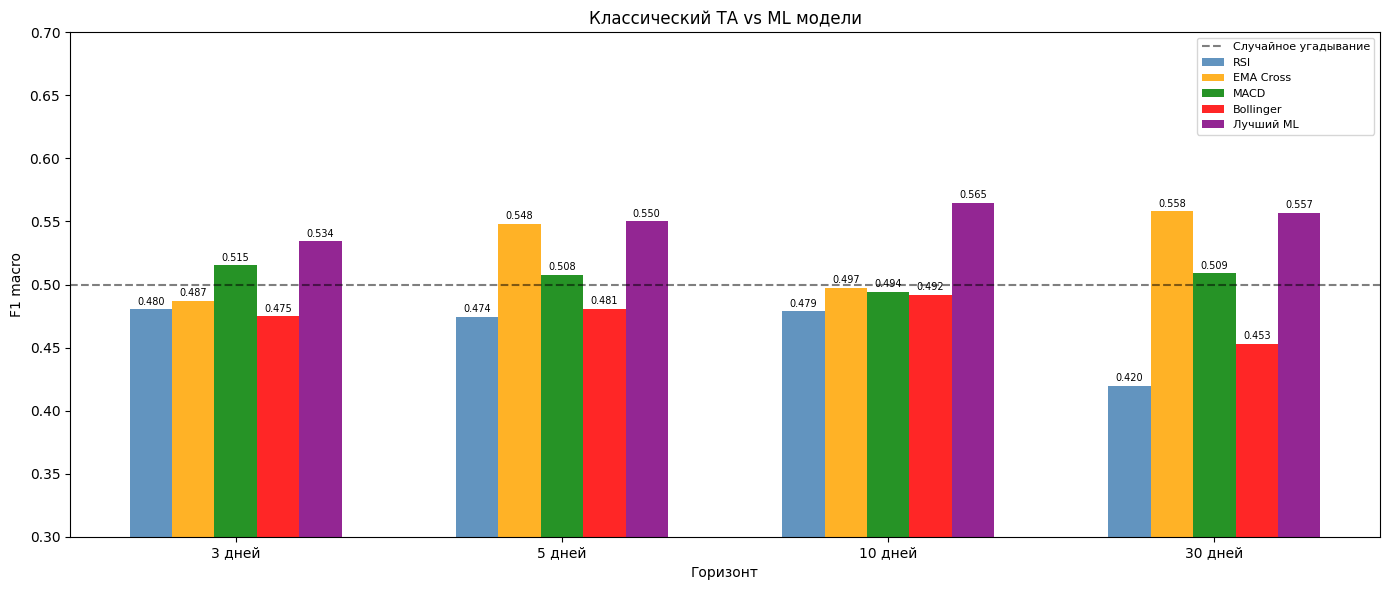

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(HORIZONS))
width = 0.13
colors = ["steelblue", "orange", "green", "red", "purple"]
labels = ["RSI", "EMA Cross", "MACD", "Bollinger", "Лучший ML"]

ta_data = [
    [rsi_results[h]["f1"]  for h in HORIZONS],
    [ema_results[h]["f1"]  for h in HORIZONS],
    [macd_results[h]["f1"] for h in HORIZONS],
    [bb_results[h]["f1"]   for h in HORIZONS],
    [ml_best[h]["f1"]      for h in HORIZONS],
]

for i, (label, data) in enumerate(zip(labels, ta_data)):
    bars = ax.bar(x + i*width, data, width, label=label,
                  color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.axhline(0.5, color="black", linestyle="--", alpha=0.5, label="Случайное угадывание")
ax.set_xlabel("Горизонт")
ax.set_ylabel("F1 macro")
ax.set_title("Классический ТА vs ML модели")
ax.set_xticks(x + width*2)
ax.set_xticklabels([f"{h} дней" for h in HORIZONS])
ax.legend(fontsize=8)
ax.set_ylim(0.3, 0.7)

plt.tight_layout()
plt.savefig("../model/ta_vs_ml.png", dpi=150)
plt.show()